Parameters

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in = [5, 9, 15, 20]
usb_c_v_tolerance = 0.1
i_in_max = 5
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

Max Fan Load Power: 33.60W


Design goals: maximize efficiency when using low power USB battery bank. Fit neatly inside pc fan air purifier case with minimal space concerns.

Design Specific Parameters

In [7]:
input_voltage_operating_points = [4.5, 9, 15, 22]
input_current_operating_points_max = [3, 3, 3, 3]
f_sw = 100e3 # Assume we use minimum frequency, given efficiency is the main goal

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = [
    min(max_load_watts, v * i) 
    for v, i in zip(input_voltage_operating_points, input_current_operating_points_max)
]

print(f"Voltages: {input_voltage_operating_points} V")
# This creates a string where each number is formatted to 2 decimal places
formatted_powers = ", ".join([f"{p:.2f}" for p in p_out_operating_points])
print(f"Calculated Operating Powers: [{formatted_powers}] W")

Voltages: [4.5, 9, 15, 22] V
Calculated Operating Powers: [13.50, 27.00, 33.60, 33.60] W


Appropriate Inductance Values

In [8]:
# Constants
ripple_ratio = 0.3 # Table1[Goal Delta I_L]
i_out_lim = 3.0

l_values = []

for v_in in input_voltage_operating_points:
    # Determine mode
    is_buck = v_in > v_out
    
    # Target Delta I_L (usually a percentage of load current)
    delta_i = ripple_ratio * i_out_lim
    
    if is_buck:
        l_calc = ((v_in - v_out) * v_out) / (delta_i * f_sw * v_in)
    else:
        # Boost formula
        l_calc = (v_in**2 * (v_out - v_in)) / (delta_i * f_sw * v_out**2)
    
    l_values.append(abs(l_calc)) # abs() handles the sign if Vin=Vout

# Final Inductor Choice (Worst Case)
required_l = max(l_values)

print(f"Calculated Inductances: {[f'{x*1e6:.2f} uH' for x in l_values]}")

Calculated Inductances: ['11.72 uH', '18.75 uH', '26.67 uH', '60.61 uH']


LM5176

In [9]:
# Gate Driver
v_gate_drive = 7.35
i_gate_drive_source = 1.8
i_gate_drive_sink = 2.2  
r_h_driver_source_pullup = 1.8
r_h_driver_source_pulldown = 1.1
r_l_driver_source_pullup = 1.7
r_l_driver_source_pulldown = 1.3
t_DT1 = 45e-9
r_gate_ext = 0.0      # External resistor
i_Q_nom = 2e-3 #V_in operating current, VEN/UVLO = 2 V, VFB = 0.9 V
i_Q_max =  4e-3

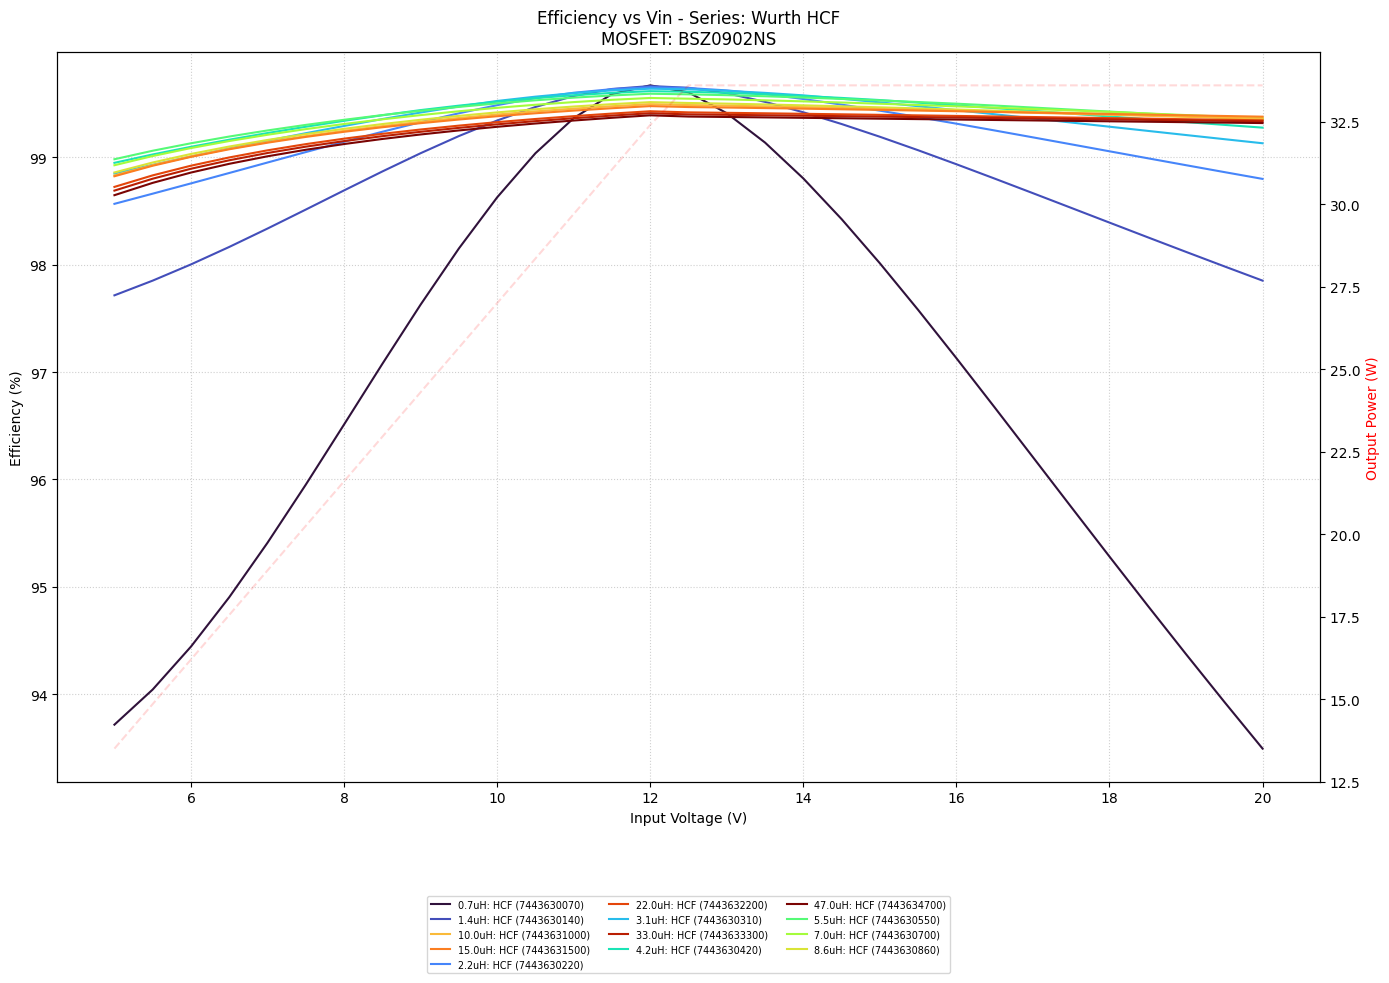

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# --- ADVANCED FILTER CONFIGURATION ---
# We use bitwise OR (|) to combine different selection criteria
# 1. Any series containing 'ERU 24'
# 2. Any series 'HCF' specifically in size '2815'

mask = (
    #(ind_df['Series'].str.contains('ERU 24', case=False, na=False)) #| 
    ((ind_df['Series'] == 'HCF') & (ind_df['Size_Code'].astype(str) == '2013'))
)

ind_df = ind_df[mask]

if ind_df.empty:
    print("No parts found matching the criteria! Check CSV naming.")
# -------------------------------------

# Use best MOSFET
best_mos_name = 'BSZ0902NS'
best_mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

def calc_efficiency_forced_ccm(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q):
    if p_out <= 0: p_out = 1e-6
    i_out = p_out / v_out
    
    # Logic for Buck vs Boost
    if v_in > v_out: # Buck
        d = v_out / v_in
        i_l_avg = i_out
        delta_il = (v_in - v_out) * d / (L * f_sw)
        v_sw_node = v_in
    else: # Boost
        d = 1 - (v_in / v_out)
        i_l_avg = i_out / (1 - d)
        delta_il = (v_in * d) / (L * f_sw)
        v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    p_dcr = i_l_rms**2 * dcr
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    total_loss = p_dcr + p_cond + p_sw + p_gate + p_ic
    return (p_out / (p_out + total_loss)) * 100

# Params
v_in_points = np.linspace(5, 20, 31)
v_out, f_sw, v_gate, i_gate_src, i_gate_snk, i_q = 12, 100e3, 7.35, 1.8, 2.2, 2e-3
max_load_watts, i_in_limit, est_eff = 33.6, 3.0, 0.9
actual_p_out = [min(max_load_watts, v * i_in_limit * est_eff) for v in v_in_points]

rdson = (best_mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(best_mos['RDSon_10V_Typ(mOhm)']) else best_mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (best_mos['Qg_10V_Typ(nC)'] if not pd.isna(best_mos['Qg_10V_Typ(nC)']) else best_mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = best_mos['Qgd_Typ(nC)']*1e-9

# Plotting setup
unique_l = sorted(ind_df['Inductance_uH'].unique())
colors = plt.cm.turbo(np.linspace(0, 1, len(unique_l))) # Using turbo for better contrast
l_color_map = dict(zip(unique_l, colors))
line_styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]

fig, ax1 = plt.subplots(figsize=(14, 10))
ax2 = ax1.twinx()

for l_val in unique_l:
    subset = ind_df[ind_df['Inductance_uH'] == l_val]
    color = l_color_map[l_val]
    for idx, (_, ind) in enumerate(subset.iterrows()):
        ls = line_styles[idx % len(line_styles)]
        eff_list = [calc_efficiency_forced_ccm(v, v_out, p, ind['Inductance_uH']*1e-6, ind['DCR_max_mOhm']*1e-3, 
                                               rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q) 
                    for v, p in zip(v_in_points, actual_p_out)]
        
        # Label includes Series and Size for clarity when filtered
        label_text = f"{l_val}uH: {ind['Series']} ({ind['Part_Number']})"
        ax1.plot(v_in_points, eff_list, color=color, linestyle=ls, label=label_text)

ax1.set_xlabel('Input Voltage (V)')
ax1.set_ylabel('Efficiency (%)')
ax2.set_ylabel('Output Power (W)', color='red')
ax2.plot(v_in_points, actual_p_out, color='red', alpha=0.15, linestyle='--', label='Power Envelope')

# Legend and Title
handles, labels = ax1.get_legend_handles_labels()
sorted_indices = np.argsort(labels)
ax1.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='x-small')

# Dynamically update title based on filters
filter_desc = f"Series: {'Wurth HCF'}"
ax1.set_title(f"Efficiency vs Vin - {filter_desc}\nMOSFET: {best_mos_name}")
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

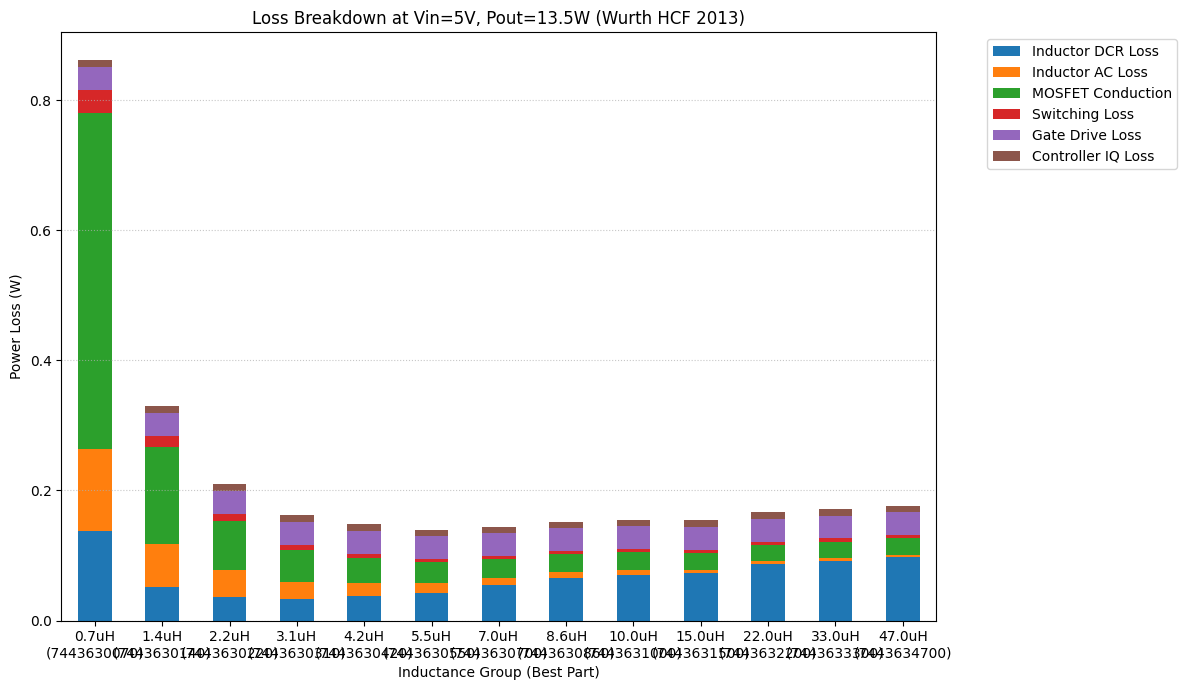

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# --- FILTER FOR CERTAIN SERIES OR SIZE ONLY ---
#ind_df = ind_df[ind_df['Size_Code'] == '2815']
ind_df = ind_df[ind_df['Size_Code'] == '2013']
#ind_df = ind_df[ind_df['Series'] == 'ERU 24']
# Best MOSFET
best_mos_name = 'BSZ0501NSI'#'BSZ0902NS'
mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

# Params
v_in = 5.0
v_out = 12.0
f_sw = 100e3
v_gate = 7.35
i_gate_src = 1.8
i_gate_snk = 2.2
i_q = 2e-3
i_in_limit = 3.0
est_eff = 0.9
p_out = v_in * i_in_limit * est_eff

rdson = (mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(mos['RDSon_10V_Typ(mOhm)']) else mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (mos['Qg_10V_Typ(nC)'] if not pd.isna(mos['Qg_10V_Typ(nC)']) else mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = mos['Qgd_Typ(nC)']*1e-9

def get_loss_breakdown(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=None):
    i_out = p_out / v_out
    # Boost mode since 5V -> 12V
    d = 1 - (v_in / v_out)
    i_l_avg = i_out / (1 - d)
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    # Inductor DC Loss
    p_dcr = i_l_rms**2 * dcr
    
    # Inductor AC/Core Loss (using parallel resistor Rp from SPICE model)
    # P_ac = (V_L_rms^2) / Rp
    if rp and not pd.isna(rp) and rp > 0:
        p_ac = ( (v_in**2 * d) + ((v_in - v_out)**2 * (1-d)) ) / rp
    else:
        p_ac = 0.0
        
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    return {
        'Inductor DCR Loss': p_dcr,
        'Inductor AC Loss': p_ac,
        'MOSFET Conduction': p_cond,
        'Switching Loss': p_sw,
        'Gate Drive Loss': p_gate,
        'Controller IQ Loss': p_ic
    }

# Find best inductor for each value at 5V (lowest DCR)
unique_l = sorted(ind_df['Inductance_uH'].unique())
breakdowns = []
labels = []

for l_val in unique_l:
    subset = ind_df[ind_df['Inductance_uH'] == l_val]
    best_ind = subset.loc[subset['DCR_max_mOhm'].idxmin()]
    
    # Pass Rp_Ohm from the dataframe
    res = get_loss_breakdown(v_in, v_out, p_out, best_ind['Inductance_uH']*1e-6, best_ind['DCR_max_mOhm']*1e-3, 
                            rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=best_ind.get('Rp_Ohm'))
    breakdowns.append(res)
    labels.append(f"{l_val}uH\n({best_ind['Part_Number']})")

df_breakdown = pd.DataFrame(breakdowns, index=labels)

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
df_breakdown.plot(kind='bar', stacked=True, ax=ax)

ax.set_title(f"Loss Breakdown at Vin=5V, Pout={p_out:.1f}W (Wurth HCF 2013)")
ax.set_ylabel("Power Loss (W)")
ax.set_xlabel("Inductance Group (Best Part)")
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('loss_breakdown_with_ac.png')

<>:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\harri\AppData\Local\Temp\ipykernel_37416\1072438664.py:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Inductance ($\mu$H)")


                                   Group_Label      Part_Number  \
77  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-333KL   
76  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-223KL   
75  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-153KL   
74  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-103KL   
67                              TDK ERU (2522)  B82559A9103A024   
68                              TDK ERU (2518)  B82559A0153A024   
69                              TDK ERU (2521)  B82559A0203A024   
73  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-682KL   
66                              TDK ERU (2519)  B82559A7682A024   
70                              TDK ERU (2521)  B82559A0303A024   

    Inductance_uH  Total_Loss_W  
77           33.0      0.106144  
76           22.0      0.106660  
75           15.0      0.107765  
74           10.0      0.110404  
67           10.0      0.110928  
68           15.0      0.111416  
69           20.0      0

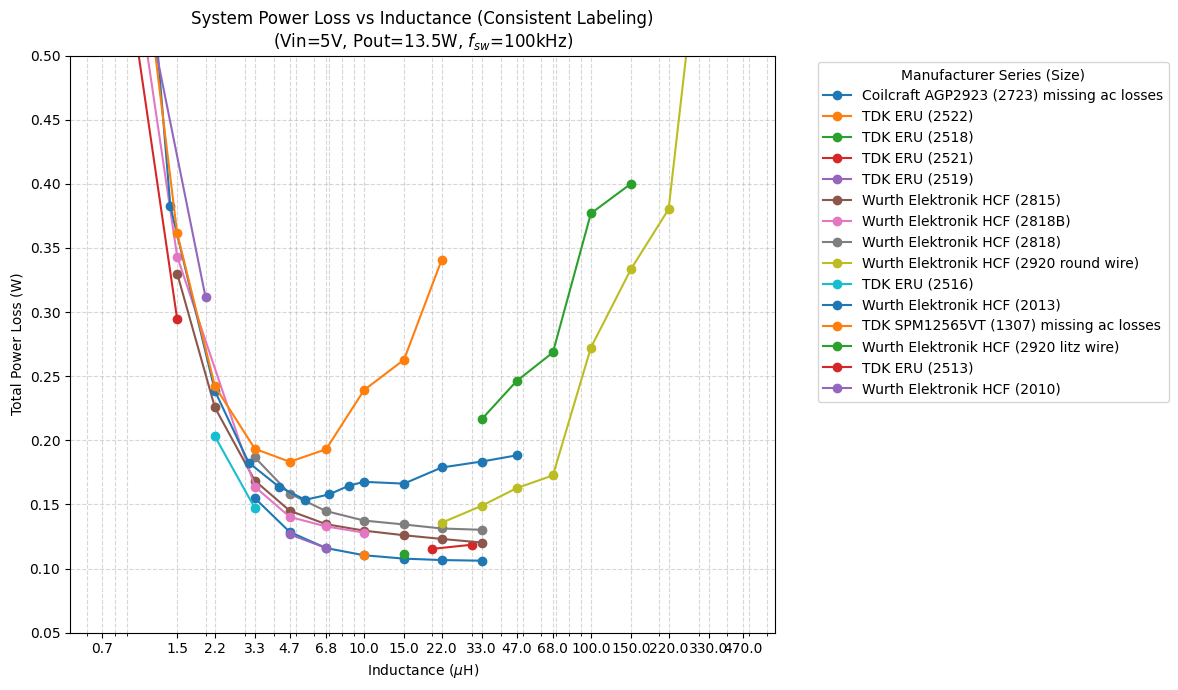

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# Handle missing size codes and clean data
ind_df['Size_Code'] = ind_df['Size_Code'].fillna('Unknown')

# Define a "Plotting Group" label - CONSISTENT VERSION
def create_group_label(row):
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'ERU 24':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return "TDK ERU 24 (25xx Footprint)"
    if row['Manufacturer'] == 'Coilcraft' and row['Series'] == 'AGP2923':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'SPM12565VT':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']})"

ind_df['Group_Label'] = ind_df.apply(create_group_label, axis=1)

# Best MOSFET (BSZ0902NS)
best_mos_name = 'BSZ0902NS'
mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

# Operating Parameters (Same as before)
v_in, v_out = 5.0, 12.0
f_sw = 100e3
v_gate = 7.35
i_gate_src, i_gate_snk = 1.8, 2.2
i_q = 2e-3
i_in_limit = 3.0
est_eff = 0.9
p_out = v_in * i_in_limit * est_eff

rdson = (mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(mos['RDSon_10V_Typ(mOhm)']) else mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (mos['Qg_10V_Typ(nC)'] if not pd.isna(mos['Qg_10V_Typ(nC)']) else mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = mos['Qgd_Typ(nC)']*1e-9

def get_total_loss(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=None):
    i_out = p_out / v_out
    d = 1 - (v_in / v_out)
    i_l_avg = i_out / (1 - d)
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    # Inductor AC/Core Loss (using parallel resistor Rp from SPICE model)
    # P_ac = (V_L_rms^2) / Rp
    if rp and not pd.isna(rp) and rp > 0:
        p_ac = ( (v_in**2 * d) + ((v_in - v_out)**2 * (1-d)) ) / rp
    else:
        p_ac = 0.0

    p_dcr = i_l_rms**2 * dcr
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    return p_dcr + p_ac + p_cond + p_sw + p_gate + p_ic

# Calculate losses
ind_df['Total_Loss_W'] = ind_df.apply(lambda row: get_total_loss(
    v_in, v_out, p_out, row['Inductance_uH']*1e-6, row['DCR_max_mOhm']*1e-3,
    rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, row['Rp_Ohm']
), axis=1)

# Group and find best within each Inductance value per Family
plot_df = ind_df.loc[ind_df.groupby(['Group_Label', 'Inductance_uH'])['Total_Loss_W'].idxmin()]
plot_df = plot_df.sort_values(['Group_Label', 'Inductance_uH'])

# Plotting
plt.figure(figsize=(12, 7))

# Sort labels by minimum loss
ordered_labels = plot_df.groupby('Group_Label')['Total_Loss_W'].min().sort_values().index

for label in ordered_labels:
    subset = plot_df[plot_df['Group_Label'] == label]
    plt.plot(subset['Inductance_uH'], subset['Total_Loss_W'], marker='o', label=label)

plt.title(f"System Power Loss vs Inductance (Consistent Labeling)\n(Vin=5V, Pout={p_out:.1f}W, $f_{{sw}}$={f_sw/1e3:.0f}kHz)")
plt.xlabel("Inductance ($\mu$H)")
plt.ylabel("Total Power Loss (W)")
plt.xscale('log')
plt.ylim([0.05,0.5])
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(title="Manufacturer Series (Size)", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ticks
unique_l = sorted(plot_df['Inductance_uH'].unique())
min_losses = plot_df.groupby('Inductance_uH')['Total_Loss_W'].min()
clusters = []
if unique_l:
    current_cluster = [unique_l[0]]
    for val in unique_l[1:]:
        if (val - current_cluster[-1]) / current_cluster[-1] < 0.20:
            current_cluster.append(val)
        else:
            clusters.append(current_cluster)
            current_cluster = [val]
    clusters.append(current_cluster)
filtered_ticks = [min(c, key=lambda x: min_losses[x]) for c in clusters]
plt.xticks(filtered_ticks, [str(t) for t in filtered_ticks])

plt.tight_layout()
plt.savefig('loss_by_family_consistent.png')

# Summary
summary = plot_df.sort_values('Total_Loss_W').head(10)[['Group_Label', 'Part_Number', 'Inductance_uH', 'Total_Loss_W']]
print(summary)